# Task 4 — Advanced Analytics (Basic)

## ApexPlanet Data Analytics Internship

This notebook applies statistical analysis, customer segmentation
and basic predictive modeling to the cleaned Online Retail dataset.

### Objectives
1. Perform descriptive statistical analysis.
2. Conduct hypothesis testing.
3. Calculate confidence intervals.
4. Segment customers using K-Means clustering.
5. Develop and evaluate a basic predictive model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
df = pd.read_csv(
    "/content/online_retail_cleaned.csv",
    dtype={
        "InvoiceNo": str,
        "StockCode": str,
        "CustomerID": str
    },
    parse_dates=["InvoiceDate"]
)

print("Dataset Shape:", df.shape)

display(df.head())

print("\nDataset Information:")
df.info()

Dataset Shape: (482254, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,SalesAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 482254 entries, 0 to 482253
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    482254 non-null  object        
 1   StockCode    482254 non-null  object        
 2   Description  482254 non-null  object        
 3   Quantity     482254 non-null  int64         
 4   InvoiceDate  482254 non-null  datetime64[ns]
 5   UnitPrice    482254 non-null  float64       
 6   CustomerID   356007 non-null  object        
 7   Country      482254 non-null  object        
 8   SalesAmount  482254 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [4]:
print("Dataset Shape:", df.shape)

print("\nDate Range:")
print("Start:", df["InvoiceDate"].min())
print("End:", df["InvoiceDate"].max())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Dataset Shape: (482254, 9)

Date Range:
Start: 2010-12-01 08:26:00
End: 2011-12-09 12:50:00

Missing Values:
InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     126247
Country             0
SalesAmount         0
dtype: int64

Duplicate Rows:
0


In [5]:
numeric_cols = [
    "Quantity",
    "UnitPrice",
    "SalesAmount"
]

descriptive_stats = df[numeric_cols].describe().T

descriptive_stats["variance"] = df[numeric_cols].var()
descriptive_stats["skewness"] = df[numeric_cols].skew()
descriptive_stats["median"] = df[numeric_cols].median()

display(descriptive_stats.round(2))

,count,mean,std,min,25%,50%,75%,max,variance,skewness,median
Quantity,482254.0,6.26,8.94,1.0,1.00,3.00,9.00,900.00,80.01,8.25,3.00
UnitPrice,482254.0,3.14,3.26,0.0,1.25,2.08,4.13,38.26,10.63,2.83,2.08
SalesAmount,482254.0,10.54,8.32,0.0,3.40,8.40,15.90,38.40,69.21,0.95,8.40


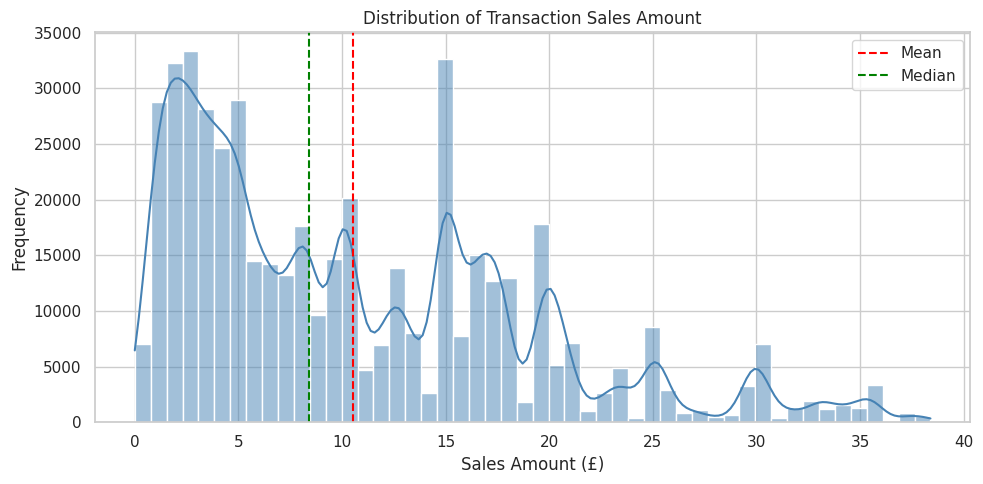

In [6]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df["SalesAmount"],
    bins=50,
    kde=True,
    color="steelblue"
)

plt.axvline(
    df["SalesAmount"].mean(),
    color="red",
    linestyle="--",
    label="Mean"
)

plt.axvline(
    df["SalesAmount"].median(),
    color="green",
    linestyle="--",
    label="Median"
)

plt.title("Distribution of Transaction Sales Amount")
plt.xlabel("Sales Amount (£)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()

plt.show()

Confidence interval for mean transaction revenue

In [7]:
sales = df["SalesAmount"].dropna()

sample_mean = sales.mean()
standard_error = stats.sem(sales)

confidence_interval = stats.t.interval(
    confidence=0.95,
    df=len(sales) - 1,
    loc=sample_mean,
    scale=standard_error
)

print(f"Mean Transaction Revenue: £{sample_mean:.2f}")

print(
    "95% Confidence Interval:",
    f"£{confidence_interval[0]:.2f}",
    "to",
    f"£{confidence_interval[1]:.2f}"
)

Mean Transaction Revenue: £10.54
95% Confidence Interval: £10.52 to £10.56


Performing t-test

In [8]:
uk_sales = df.loc[
    df["Country"] == "United Kingdom",
    "SalesAmount"
].dropna()

germany_sales = df.loc[
    df["Country"] == "Germany",
    "SalesAmount"
].dropna()

t_stat, p_value = stats.ttest_ind(
    uk_sales,
    germany_sales,
    equal_var=False
)

print(f"UK Mean: £{uk_sales.mean():.2f}")
print(f"Germany Mean: £{germany_sales.mean():.2f}")

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")

if p_value < 0.05:
    print("Reject the null hypothesis.")
else:
    print("Fail to reject the null hypothesis.")

UK Mean: £10.05
Germany Mean: £16.73
T-statistic: -79.8704
P-value: 0.000000
Reject the null hypothesis.


Chi-Square test

In [9]:
chi_df = df[
    df["Country"].isin([
        "United Kingdom",
        "Germany",
        "France"
    ])
].copy()

chi_df["Weekday"] = chi_df["InvoiceDate"].dt.day_name()

contingency_table = pd.crosstab(
    chi_df["Country"],
    chi_df["Weekday"]
)

display(contingency_table)

chi2, p_value, dof, expected = stats.chi2_contingency(
    contingency_table
)

print(f"Chi-square statistic: {chi2:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"Degrees of freedom: {dof}")

if p_value < 0.05:
    print("Reject the null hypothesis.")
else:
    print("Fail to reject the null hypothesis.")

Weekday,Friday,Monday,Sunday,Thursday,Tuesday,Wednesday
Country,,,,,,
France,1355,1086,579,1596,1146,1621
Germany,1606,1505,720,1833,1086,1146
United Kingdom,65645,79571,56529,82995,84203,76872


Chi-square statistic: 882.9408
P-value: 0.000000
Degrees of freedom: 10
Reject the null hypothesis.


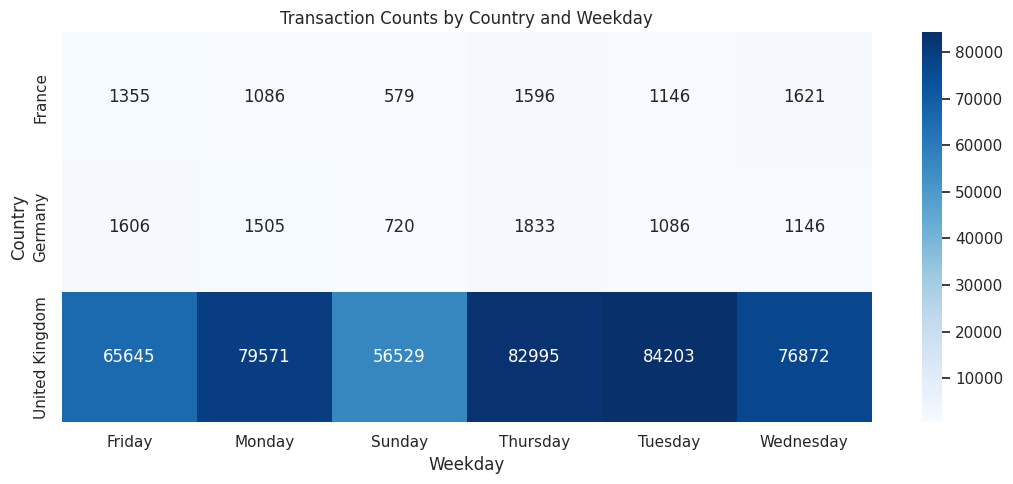

In [10]:
plt.figure(figsize=(11, 5))

sns.heatmap(
    contingency_table,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Transaction Counts by Country and Weekday")
plt.xlabel("Weekday")
plt.ylabel("Country")
plt.tight_layout()

plt.show()

# Part 2: Customer Segmentation

Customer segmentation using RFM analysis, K-Means clustering,
the elbow method and Principal Component Analysis (PCA).

In [11]:
customer_df = df.dropna(
    subset=["CustomerID"]
).copy()

customer_df["CustomerID"] = (
    customer_df["CustomerID"]
    .astype(str)
    .str.replace(r"\.0$", "", regex=True)
)

print("Customer transactions:", len(customer_df))
print(
    "Unique customers:",
    customer_df["CustomerID"].nunique()
)

display(customer_df.head())

Customer transactions: 356007
Unique customers: 4185


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,SalesAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


RFM Features

In [12]:
reference_date = (
    customer_df["InvoiceDate"].max()
    + pd.Timedelta(days=1)
)

rfm = customer_df.groupby("CustomerID").agg(
    LastPurchase=("InvoiceDate", "max"),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("SalesAmount", "sum")
).reset_index()

rfm["Recency"] = (
    reference_date - rfm["LastPurchase"]
).dt.days

rfm = rfm[
    ["CustomerID", "Recency", "Frequency", "Monetary"]
]

display(rfm.head())

print("RFM dataset shape:", rfm.shape)

,CustomerID,Recency,Frequency,Monetary
0,12347,2,7,3056.42
1,12348,249,3,111.08
2,12349,19,1,1105.40
3,12350,310,1,294.40
4,12352,36,7,1385.74


RFM dataset shape: (4185, 4)


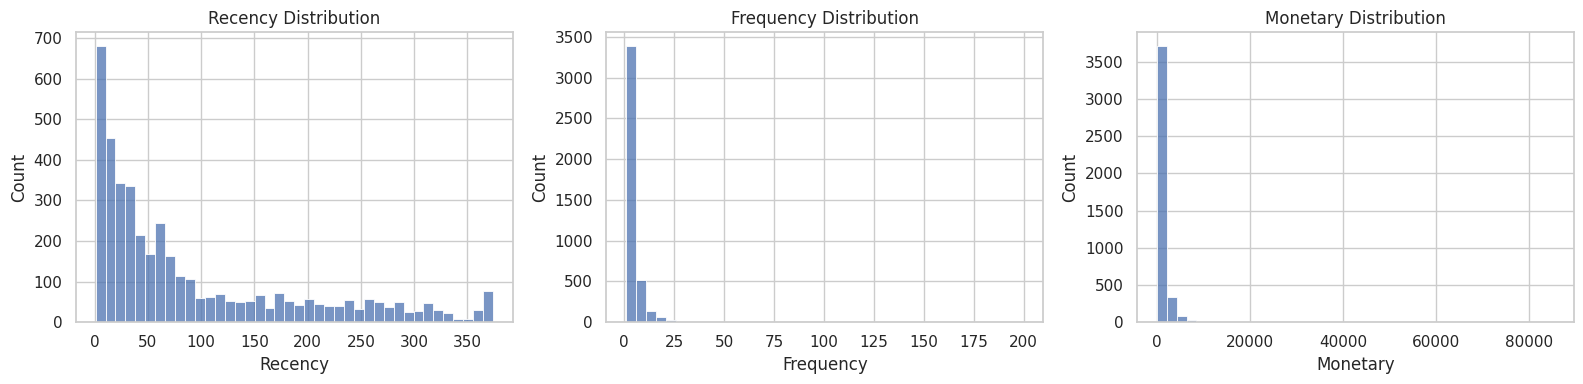

In [13]:
fig, axes = plt.subplots(
    1, 3,
    figsize=(16, 4)
)

features = [
    "Recency",
    "Frequency",
    "Monetary"
]

for ax, feature in zip(axes, features):
    sns.histplot(
        rfm[feature],
        bins=40,
        ax=ax
    )

    ax.set_title(f"{feature} Distribution")
    ax.set_xlabel(feature)

plt.tight_layout()
plt.show()

In [14]:
rfm_features = rfm[
    ["Recency", "Frequency", "Monetary"]
].copy()

rfm_log = np.log1p(rfm_features)

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_log)

print("Scaled data shape:", rfm_scaled.shape)

display(
    pd.DataFrame(
        rfm_scaled,
        columns=rfm_features.columns
    ).head()
)

Scaled data shape: (4185, 3)


,Recency,Frequency,Monetary
0,-2.057518,1.157151,1.515565
1,1.262131,0.103701,-1.191448
2,-0.633600,-0.949749,0.683298
3,1.426004,-0.949749,-0.397945
4,-0.171862,1.157151,0.868217


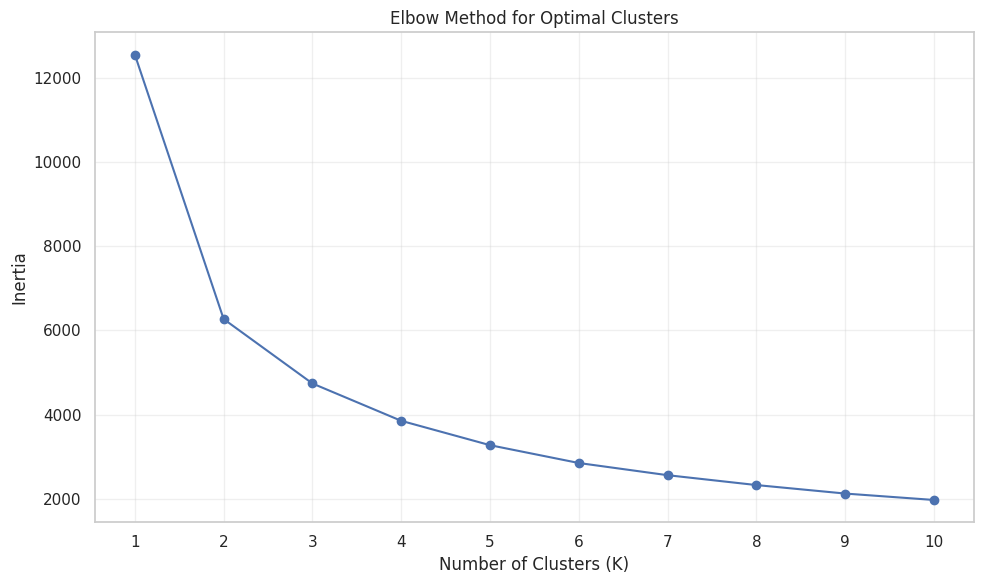

In [15]:
inertias = []

k_values = range(1, 11)

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(rfm_scaled)

    inertias.append(model.inertia_)

plt.figure(figsize=(10, 6))

plt.plot(
    list(k_values),
    inertias,
    marker="o"
)

plt.title("Elbow Method for Optimal Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(list(k_values))
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

In [16]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

k_range = range(2, 9)

for k in k_range:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(rfm_scaled)

    score = silhouette_score(
        rfm_scaled,
        labels
    )

    silhouette_scores.append(score)

results = pd.DataFrame({
    "Clusters": list(k_range),
    "Silhouette Score": silhouette_scores
})

display(results.round(4))



,Clusters,Silhouette Score
0,2,0.4280
1,3,0.3266
2,4,0.3277
3,5,0.2883
4,6,0.2880
5,7,0.2800
6,8,0.2881


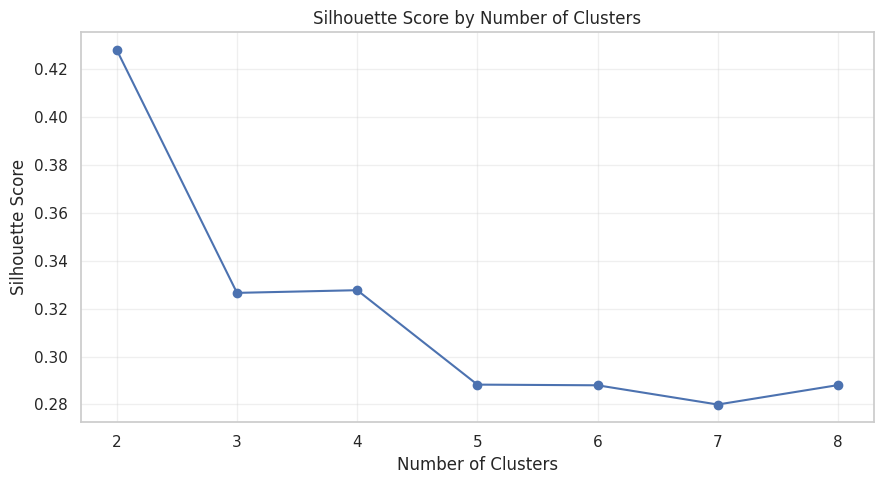

In [17]:
plt.figure(figsize=(9, 5))

plt.plot(
    results["Clusters"],
    results["Silhouette Score"],
    marker="o"
)

plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.xticks(list(k_range))
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

In [18]:
optimal_k = 4

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(
    rfm_scaled
)

print("Customers in each cluster:")

print(
    rfm["Cluster"]
    .value_counts()
    .sort_index()
)

display(rfm.head())

Customers in each cluster:
Cluster
0     826
1     777
2    1450
3    1132
Name: count, dtype: int64


,CustomerID,Recency,Frequency,Monetary,Cluster
0,12347,2,7,3056.42,1
1,12348,249,3,111.08,2
2,12349,19,1,1105.40,0
3,12350,310,1,294.40,2
4,12352,36,7,1385.74,3


In [19]:
cluster_profile = rfm.groupby("Cluster").agg(
    Customers=("CustomerID", "count"),
    Avg_Recency=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Monetary=("Monetary", "mean"),
    Total_Revenue=("Monetary", "sum")
).round(2)

cluster_profile["Customer_Percentage"] = (
    cluster_profile["Customers"]
    / len(rfm)
    * 100
).round(2)

display(cluster_profile)

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue,Customer_Percentage
Cluster,,,,,,
0,826,21.35,1.94,358.70,296283.17,19.74
1,777,13.07,11.65,3025.28,2350643.69,18.57
2,1450,189.87,1.27,223.67,324323.85,34.65
3,1132,74.97,3.71,1044.69,1182586.93,27.05


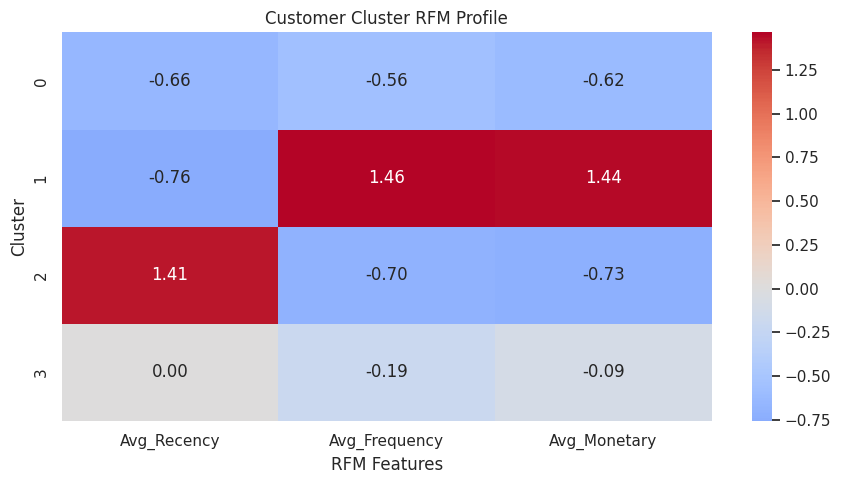

In [20]:
profile_features = cluster_profile[
    ["Avg_Recency", "Avg_Frequency", "Avg_Monetary"]
]

normalized_profile = (
    profile_features - profile_features.mean()
) / profile_features.std().replace(0, 1)

plt.figure(figsize=(9, 5))

sns.heatmap(
    normalized_profile,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Customer Cluster RFM Profile")
plt.xlabel("RFM Features")
plt.ylabel("Cluster")
plt.tight_layout()

plt.show()

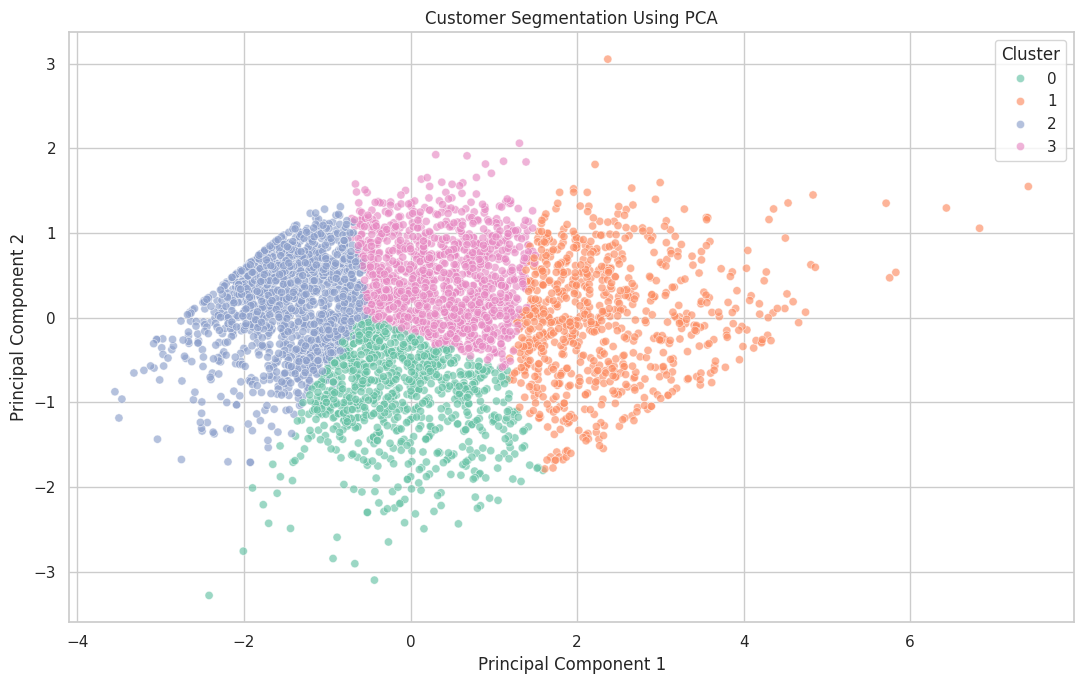

Total variance explained: 92.47 %


In [21]:
pca = PCA(n_components=2)

rfm_pca = pca.fit_transform(
    rfm_scaled
)

pca_df = pd.DataFrame({
    "PC1": rfm_pca[:, 0],
    "PC2": rfm_pca[:, 1],
    "Cluster": rfm["Cluster"].values
})

plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set2",
    alpha=0.65,
    s=35
)

plt.title("Customer Segmentation Using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.tight_layout()

plt.show()

print(
    "Total variance explained:",
    round(
        pca.explained_variance_ratio_.sum() * 100,
        2
    ),
    "%"
)

In [22]:
rfm.to_csv(
    "/content/customer_segments.csv",
    index=False
)

cluster_profile.to_csv(
    "/content/customer_cluster_profile.csv"
)

print("Customer segmentation results exported.")

Customer segmentation results exported.


# Part 3: Predictive Modeling

This section develops a basic Linear Regression model
to predict daily revenue using historical sales patterns.

In [23]:
daily_sales = (
    df.groupby(df["InvoiceDate"].dt.normalize())
      ["SalesAmount"]
      .sum()
      .reset_index()
)

daily_sales.columns = ["Date", "Revenue"]

daily_sales = daily_sales.set_index("Date")

# Include days with no recorded transactions.
daily_sales = daily_sales.asfreq("D", fill_value=0)

daily_sales = daily_sales.reset_index()

print("Daily records:", len(daily_sales))
display(daily_sales.head())

Daily records: 374


,Date,Revenue
0,2010-12-01,27636.12
1,2010-12-02,22918.20
2,2010-12-03,20231.37
3,2010-12-04,0.00
4,2010-12-05,20242.67


In [24]:
daily_sales["Revenue_Lag_1"] = (
    daily_sales["Revenue"].shift(1)
)

daily_sales["Revenue_Lag_7"] = (
    daily_sales["Revenue"].shift(7)
)

daily_sales["Rolling_Mean_7"] = (
    daily_sales["Revenue"]
    .shift(1)
    .rolling(window=7)
    .mean()
)

daily_sales["DayOfWeek"] = (
    daily_sales["Date"].dt.dayofweek
)

daily_sales["Month"] = (
    daily_sales["Date"].dt.month
)

model_df = daily_sales.dropna().copy()

display(model_df.head())

,Date,Revenue,Revenue_Lag_1,Revenue_Lag_7,Rolling_Mean_7,DayOfWeek,Month
7,2010-12-08,24795.46,26036.75,27636.12,21429.344286,2,12
8,2010-12-09,26161.61,24795.46,22918.20,21023.535714,3,12
9,2010-12-10,24021.16,26161.61,20231.37,21486.880000,4,12
10,2010-12-11,0.00,24021.16,0.00,22028.278571,5,12
11,2010-12-12,10085.59,0.00,20242.67,22028.278571,6,12


In [25]:
features = [
    "Revenue_Lag_1",
    "Revenue_Lag_7",
    "Rolling_Mean_7",
    "DayOfWeek",
    "Month"
]

X = model_df[features]
y = model_df["Revenue"]

split_index = int(len(model_df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

test_dates = model_df["Date"].iloc[split_index:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print(
    "Training period:",
    model_df["Date"].iloc[0],
    "to",
    model_df["Date"].iloc[split_index - 1]
)

print(
    "Testing period:",
    model_df["Date"].iloc[split_index],
    "to",
    model_df["Date"].iloc[-1]
)

Training samples: 293
Testing samples: 74
Training period: 2010-12-08 00:00:00 to 2011-09-26 00:00:00
Testing period: 2011-09-27 00:00:00 to 2011-12-09 00:00:00


In [26]:
model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [27]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print("Model Evaluation")
print("------------------------")

print(f"MAE: £{mae:,.2f}")
print(f"RMSE: £{rmse:,.2f}")
print(f"R² Score: {r2:.4f}")

Model Evaluation
------------------------
MAE: £6,333.93
RMSE: £7,868.82
R² Score: 0.5060


In [28]:
baseline_pred = X_test["Revenue_Lag_1"]

baseline_mae = mean_absolute_error(
    y_test,
    baseline_pred
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_pred
    )
)

comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Previous-Day Baseline"
    ],
    "MAE": [
        mae,
        baseline_mae
    ],
    "RMSE": [
        rmse,
        baseline_rmse
    ]
})

display(comparison.round(2))

,Model,MAE,RMSE
0,Linear Regression,6333.93,7868.82
1,Previous-Day Baseline,10992.60,14118.62


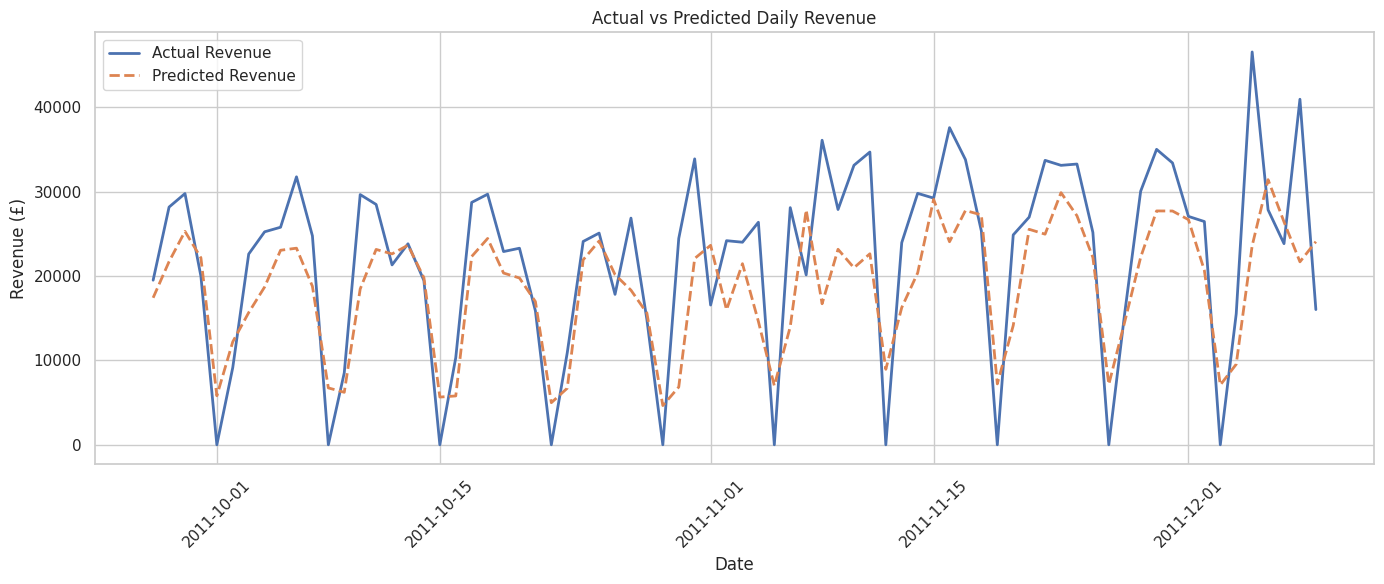

In [29]:
plt.figure(figsize=(14, 6))

plt.plot(
    test_dates,
    y_test,
    label="Actual Revenue",
    linewidth=2
)

plt.plot(
    test_dates,
    y_pred,
    label="Predicted Revenue",
    linestyle="--",
    linewidth=2
)

plt.title("Actual vs Predicted Daily Revenue")
plt.xlabel("Date")
plt.ylabel("Revenue (£)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

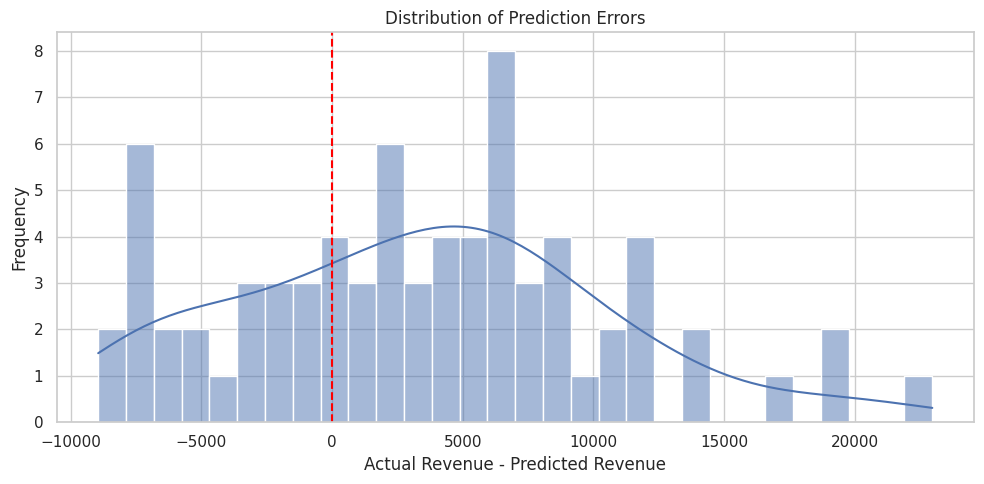

In [30]:
residuals = y_test - y_pred

plt.figure(figsize=(10, 5))

sns.histplot(
    residuals,
    bins=30,
    kde=True
)

plt.axvline(
    0,
    color="red",
    linestyle="--"
)

plt.title("Distribution of Prediction Errors")
plt.xlabel("Actual Revenue - Predicted Revenue")
plt.ylabel("Frequency")
plt.tight_layout()

plt.show()

In [31]:
from sklearn.pipeline import make_pipeline

standardized_model = make_pipeline(
    StandardScaler(),
    LinearRegression()
)

standardized_model.fit(X_train, y_train)

standardized_coefficients = (
    standardized_model.named_steps[
        "linearregression"
    ].coef_
)

feature_importance = pd.DataFrame({
    "Feature": features,
    "Coefficient": standardized_coefficients
})

feature_importance["Absolute_Importance"] = (
    feature_importance["Coefficient"].abs()
)

feature_importance = (
    feature_importance
    .sort_values(
        "Absolute_Importance",
        ascending=False
    )
)

display(feature_importance)

print("\nTop 3 Features:")
display(feature_importance.head(3))

,Feature,Coefficient,Absolute_Importance
1,Revenue_Lag_7,3633.784933,3633.784933
0,Revenue_Lag_1,1311.555955,1311.555955
3,DayOfWeek,-1274.427574,1274.427574
4,Month,-546.038074,546.038074
2,Rolling_Mean_7,323.042316,323.042316



Top 3 Features:


,Feature,Coefficient,Absolute_Importance
1,Revenue_Lag_7,3633.784933,3633.784933
0,Revenue_Lag_1,1311.555955,1311.555955
3,DayOfWeek,-1274.427574,1274.427574


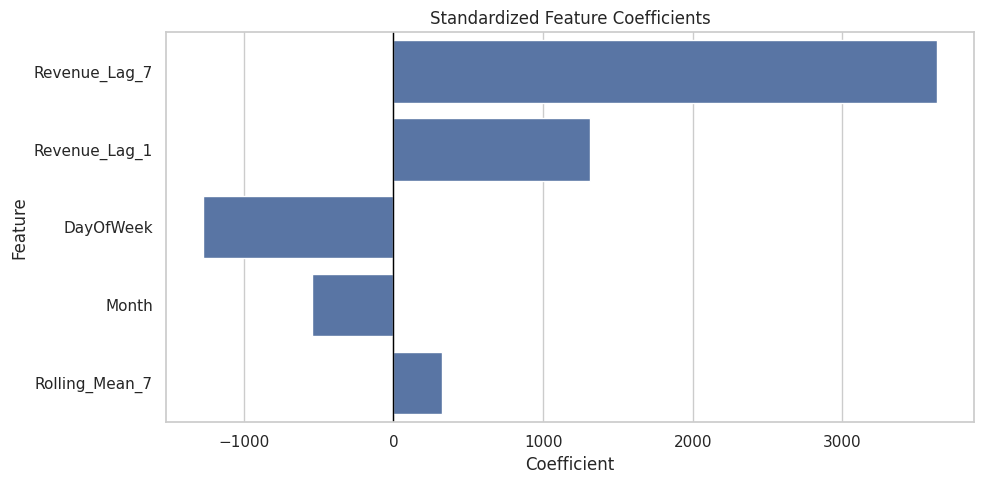

In [32]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=feature_importance,
    x="Coefficient",
    y="Feature"
)

plt.axvline(
    0,
    color="black",
    linewidth=1
)

plt.title("Standardized Feature Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.tight_layout()

plt.show()

In [33]:
prediction_results = pd.DataFrame({
    "Date": test_dates.values,
    "Actual_Revenue": y_test.values,
    "Predicted_Revenue": y_pred,
    "Absolute_Error": np.abs(
        y_test.values - y_pred
    )
})

prediction_results.to_csv(
    "/content/daily_revenue_predictions.csv",
    index=False
)

feature_importance.to_csv(
    "/content/feature_importance.csv",
    index=False
)

print("Prediction results exported successfully!")

Prediction results exported successfully!


## Predictive Modeling Findings

A Linear Regression model was developed to predict daily
revenue using historical sales information.

The dataset was split chronologically into 80% training
data and 20% testing data.


### Baseline Comparison

The model was compared with a previous-day revenue
baseline to evaluate whether it offered an improvement.


### Limitations

The dataset covers approximately one year, with
incomplete first and final months. Days without recorded
transactions were treated as zero-revenue days.

The model uses historical observed revenue and is intended
as a basic predictive analytics exercise rather than a
production-ready forecasting system.